In [8]:
%load_ext autoreload
%autoreload 2

# Set plotting parameters for figures
from matplotlib import rcParams
rcParams['font.family'] = 'Arial'
rcParams['pdf.fonttype'] = 42  # Use TrueType fonts
rcParams['axes.linewidth'] = 0.5
rcParams['xtick.major.width'] = 0.5
rcParams['ytick.major.width'] = 0.5
rcParams['savefig.dpi'] = 300  # Ensure a high resolution

# Import catrace functions and load dataset configuration
from catrace.exp_collection import read_df
from catrace.dataset import load_dataset_config
dsconfig = load_dataset_config('../dataset_configs/juvenile_dataset_t7.json')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [9]:
from catrace.exp_collection import concatenate_df_from_db
all_dff = concatenate_df_from_db(dsconfig.processed_trace_dir, dsconfig.exp_list)

# Select some neurons that are responsive to both odors
cut_time = 2.3 # The traces showed be shifted to the left by 2.3s, so that the odor onset is approximately 2s
cut_frame = int(cut_time * dsconfig.frame_rate)
begin_time = cut_time +0
begin_frame = int(begin_time * dsconfig.frame_rate)
total_time = 12 # Total time to plot, 10s
total_frame = int(total_time * dsconfig.frame_rate)
frame_range = (begin_frame, begin_frame + total_frame) # Frame range to select from the saved firing rate dataframe

# Select the frames
from catrace.process_time_trace import select_time_points
dff = select_time_points(all_dff, frame_range)



2021-07-15-DpOBEM-N2_Dp None
2021-07-16-DpOBEM-N3_Dp None
2021-12-10-DpOBEM-N4_Dp None
2021-12-31-DpOBEM-N7_Dp None
2022-02-13-DpOBEM-N10_Dp None
2022-02-20-DpOBEM-N11_Dp None
2021-02-05-DpOBEM-JH9_Dp None
2021-03-18-DpOBEM-JH10_Dp None
2021-03-19-DpOBEM-JH10_Dp None
2021-04-02-DpOBEM-JH11_Dp None
2021-04-03-DpOBEM-JH11_Dp None
2021-05-01-DpOBEM-JH13_Dp None
2021-05-22-DpOBEM-JH14_Dp None
2021-09-15-DpOBEM-JH20_Dp None
2021-09-17-DpOBEM-JH20_Dp None
2021-09-18-DpOBEM-JH20_Dp None
2021-07-30-DpOBEM-JH17_Dp None
2021-07-31-DpOBEM-JH17_Dp None
2021-09-02-DpOBEM-JH18_Dp None
2021-09-03-DpOBEM-JH18_Dp None
2021-09-04-DpOBEM-JH18_Dp None
2021-09-29-DpOBEM-JH21_Dp None
2021-10-01-DpOBEM-JH21_Dp None
2021-10-02-DpOBEM-JH21_Dp None
2021-10-14-DpOBEM-JH22_Dp None
2021-11-10-DpOBEM-JH23_Dp None
2021-11-11-DpOBEM-JH23_Dp None
2021-11-14-DpOBEM-JH23_Dp None
2021-11-24-DpOBEM-JH24_Dp None
2021-11-27-DpOBEM-JH24_Dp None
2021-11-26-DpOBEM-JH24_Dp None


In [10]:
import os
import pandas as pd
file_path = os.path.join(dsconfig.results_dir, 'offset_responsive_cluster')
os.makedirs(file_path, exist_ok=True)
# Read the matched labels
matched_label_df = pd.read_pickle(os.path.join(file_path, 'matched_cluster_labels.pkl'))

In [11]:
import numpy as np
import matplotlib.pyplot as plt
def plot_heatmap_sorted_by_cluster(dff_sorted, labels_sorted, cbar_label='Firing rate', tick_frames=None):
    fig, ax = plt.subplots(figsize=(4, 4))
    img = ax.matshow(dff_sorted.values.T, aspect='auto', cmap='viridis', interpolation='none', vmin=0, vmax=5)
    # Add colorbar
    cbar = fig.colorbar(img, ax=ax)
    cbar.set_label(cbar_label)
    ax.set_xlabel('Frame')
    ax.set_ylabel('Neuron (sorted by cluster)')


    # # draw horizontal lines between clusters
    cluster_changes = np.where(np.diff(labels_sorted) != 0)[0]
    for c in cluster_changes:
        ax.axhline(c + 0.5, color='white', linewidth=1)

    # Remove the axis lines on all four sides of the axis
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_visible(False)
    # Remove the ticks too
    ax.set_xticks([])
    ax.set_yticks([])

    if tick_frames is not None:
        ax.set_xticks(tick_frames)

    return fig, ax

C:\Users\hubob\AppData\Local\Temp\ipykernel_30012\2441926798.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dff_odor = dff_odor.groupby(level=['odor', 'time']).mean()
C:\Users\hubob\AppData\Local\Temp\ipykernel_30012\2441926798.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  labels_sorted = labels[sorted_indices]


Sorting...
Plotting...


C:\Users\hubob\AppData\Local\Temp\ipykernel_30012\2441926798.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dff_odor = dff_odor.groupby(level=['odor', 'time']).mean()
C:\Users\hubob\AppData\Local\Temp\ipykernel_30012\2441926798.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  labels_sorted = labels[sorted_indices]


Sorting...
Plotting...


C:\Users\hubob\AppData\Local\Temp\ipykernel_30012\2441926798.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dff_odor = dff_odor.groupby(level=['odor', 'time']).mean()
C:\Users\hubob\AppData\Local\Temp\ipykernel_30012\2441926798.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  labels_sorted = labels[sorted_indices]


...

Sorting...
Plotting...


C:\Users\hubob\AppData\Local\Temp\ipykernel_30012\2441926798.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dff_odor = dff_odor.groupby(level=['odor', 'time']).mean()
C:\Users\hubob\AppData\Local\Temp\ipykernel_30012\2441926798.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  labels_sorted = labels[sorted_indices]


Sorting...
Plotting...


C:\Users\hubob\AppData\Local\Temp\ipykernel_30012\2441926798.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dff_odor = dff_odor.groupby(level=['odor', 'time']).mean()
C:\Users\hubob\AppData\Local\Temp\ipykernel_30012\2441926798.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  labels_sorted = labels[sorted_indices]


Sorting...
Plotting...


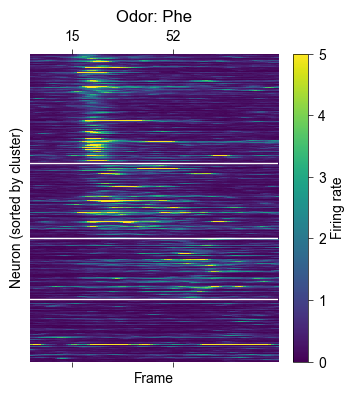

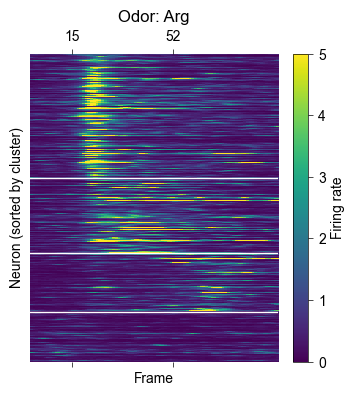

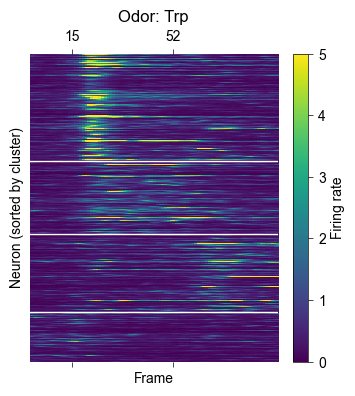

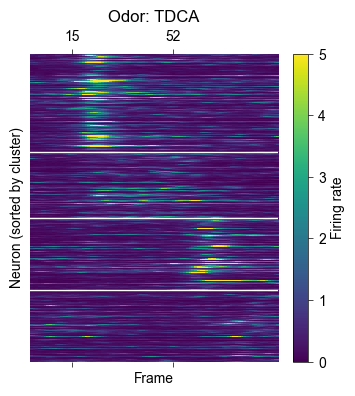

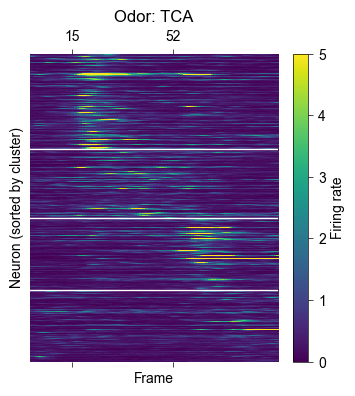

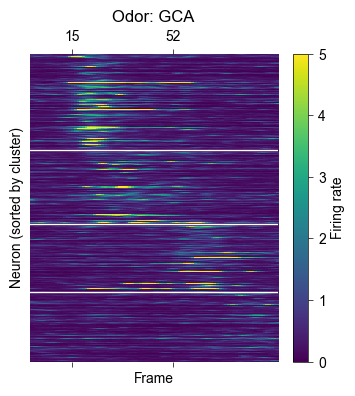

In [12]:
from catrace.process_time_trace import select_odors_df
def extract_dff_odor(dff, odor):
    dff_odor = select_odors_df(dff, [odor])
    dff_odor = dff_odor.groupby(level=['odor', 'time']).mean()
    return dff_odor

def sort_dff_by_cluster(dff, labels):
    sorted_indices = np.argsort(labels)
    dff_sorted = dff.iloc[:, sorted_indices]
    labels_sorted = labels[sorted_indices]
    return dff_sorted, labels_sorted

from catrace.for_paper import save_figure_for_paper
import os

paper_fig_root_dir = '../../figures_for_paper'
dataset_name = 'juvenile'
paper_fig_dir = os.path.join(paper_fig_root_dir, dataset_name, 'offset_cluster')
os.makedirs(paper_fig_dir, exist_ok=True)

odors = dsconfig.odors_stimuli
#odors = ['Phe']
for odor in odors:
    dff_odor = extract_dff_odor(dff, odor)
    labels = matched_label_df[odor]
    print('Sorting...')
    dff_sorted, labels_sorted = sort_dff_by_cluster(dff_odor, labels)
    print('Plotting...')
    tick_time = np.array([2, 7])
    tick_frames = (tick_time * dsconfig.frame_rate).astype(int)
    fig, ax = plot_heatmap_sorted_by_cluster(dff_sorted, labels_sorted, tick_frames=tick_frames)
    ax.set_title(f'Odor: {odor}')
    # Save figure
    save_figure_for_paper(fig, f'offset_cluster_heatmap_{odor}', paper_fig_dir, save_eps=True)